# RQ3 - Model Comparison

**Research question:** How do traditional machine learning models compare with neural network models in predicting short-form video trend labels?

This notebook is intentionally sectioned so progress can be inspected step by step. It displays results inline and does not save result tables, figures, or trained models to disk.

## 1. Experiment Setup

Use the existing processed train/validation/test splits. The validation set is used for model comparison and model selection; the test set is only used after selecting the strongest candidate models.

In [1]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 49
TARGET = "trend_label"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_PATH = DATA_DIR / "train.csv"
VALIDATION_PATH = DATA_DIR / "validation.csv"
TEST_PATH = DATA_DIR / "test.csv"

## 2. Load Data And Sanity Checks

Check split sizes, target balance, and whether the three splits share the same columns.

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(validation_df), len(test_df)],
        "columns": [train_df.shape[1], validation_df.shape[1], test_df.shape[1]],
    }
)

same_columns = (
    list(train_df.columns) == list(validation_df.columns)
    and list(train_df.columns) == list(test_df.columns)
)

display(split_summary)
print(f"All splits have identical columns: {same_columns}")
display(train_df.head())

,split,rows,columns
0,train,33655,46
1,validation,7212,46
2,test,7212,46


All splits have identical columns: True


,platform,country,region,language,category,hashtag,sound_type,week_of_year,duration_sec,views,...,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate,publish_month,publish_day,trend_label
0,tiktok,se,europe,sv,news,#booktok,trending,15,21,134960,...,11318,0.059684,0.001704,83.862,0.059684,0.007187,0.007432,4,12,declining
1,tiktok,es,europe,es,science,#grwm,trending,15,15,98468,...,5909,0.043050,0.000975,60.009,0.043050,0.006764,0.003737,4,13,rising
2,tiktok,fr,europe,fr,gaming,#dance,trending,28,58,294112,...,22034,0.057975,0.000683,74.917,0.057975,0.008079,0.005120,7,11,seasonal
3,youtube,co,south america,es,diy,#fyp,original,27,63,160850,...,5677,0.026764,0.001958,35.294,0.026764,0.003780,0.002990,7,5,rising
4,tiktok,it,europe,it,tech,#fashion,original,24,38,211401,...,28214,0.100298,0.004305,133.462,0.100298,0.014480,0.012015,6,11,rising


,split,class,count,percentage
0,train,declining,8402,24.97
1,train,rising,8471,25.17
2,train,seasonal,8502,25.26
3,train,stable,8280,24.60
4,validation,declining,1800,24.96
5,validation,rising,1816,25.18
6,validation,seasonal,1822,25.26
7,validation,stable,1774,24.60
8,test,declining,1801,24.97
9,test,rising,1815,25.17


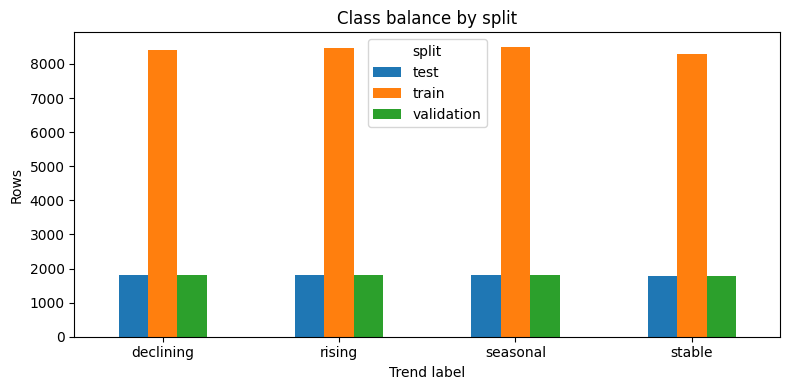

In [3]:
def class_balance_frame(df, split_name):
    counts = df[TARGET].value_counts().sort_index()
    percentages = df[TARGET].value_counts(normalize=True).sort_index() * 100
    return pd.DataFrame(
        {
            "split": split_name,
            "class": counts.index,
            "count": counts.values,
            "percentage": percentages.round(2).values,
        }
    )

class_balance = pd.concat(
    [
        class_balance_frame(train_df, "train"),
        class_balance_frame(validation_df, "validation"),
        class_balance_frame(test_df, "test"),
    ],
    ignore_index=True,
)

display(class_balance)

pivot = class_balance.pivot(index="class", columns="split", values="count")
ax = pivot.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Class balance by split")
ax.set_xlabel("Trend label")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

## 3. Feature Schema

Use all processed columns except `trend_label` as predictors. Numeric features are imputed and scaled; categorical features are imputed and one-hot encoded. This gives each model the same input representation.

In [4]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_validation = validation_df.drop(columns=[TARGET])
y_validation = validation_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

schema_summary = pd.DataFrame(
    {
        "feature_type": ["numeric", "categorical"],
        "count": [len(numeric_features), len(categorical_features)],
        "features": [", ".join(numeric_features), ", ".join(categorical_features)],
    }
)

display(schema_summary)

,feature_type,count,features
0,numeric,29,"week_of_year, duration_sec, views, likes, comm..."
1,categorical,16,"platform, country, region, language, category,..."


In [5]:
cardinality = (
    X_train[categorical_features]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .rename("unique_values")
    .reset_index()
    .rename(columns={"index": "categorical_feature"})
)

display(cardinality)

,categorical_feature,unique_values
0,hashtag,41
1,country,30
2,category,19
3,language,19
4,genre,14
5,device_brand,9
6,publish_dayofweek,7
7,region,6
8,traffic_source,6
9,event_season,5


## 4. Shared Preprocessing And Evaluation Helpers

The helper below trains a full pipeline and returns validation metrics. Macro metrics are emphasised because the task is multiclass and we want each trend class to contribute equally.

In [6]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )


def evaluate_predictions(model_name, split_name, y_true, y_pred, elapsed_seconds=None):
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "fit_seconds": elapsed_seconds,
    }


def fit_and_validate(model_name, estimator):
    pipeline = Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", estimator),
        ]
    )

    start = time.time()
    pipeline.fit(X_train, y_train)
    elapsed_seconds = time.time() - start

    validation_pred = pipeline.predict(X_validation)
    metrics = evaluate_predictions(
        model_name,
        "validation",
        y_validation,
        validation_pred,
        elapsed_seconds=elapsed_seconds,
    )

    display(pd.DataFrame([metrics]).round(4))
    print(classification_report(y_validation, validation_pred, zero_division=0))

    return pipeline, metrics, validation_pred


def plot_confusion(y_true, y_pred, title):
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Baseline Model

A majority-class baseline gives a minimum reference point. Models should comfortably beat this before their differences are meaningful.

,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds
0,Dummy majority baseline,validation,0.2526,0.0632,0.25,0.1008,0.1019,0.3099


              precision    recall  f1-score   support

   declining       0.00      0.00      0.00      1800
      rising       0.00      0.00      0.00      1816
    seasonal       0.25      1.00      0.40      1822
      stable       0.00      0.00      0.00      1774

    accuracy                           0.25      7212
   macro avg       0.06      0.25      0.10      7212
weighted avg       0.06      0.25      0.10      7212



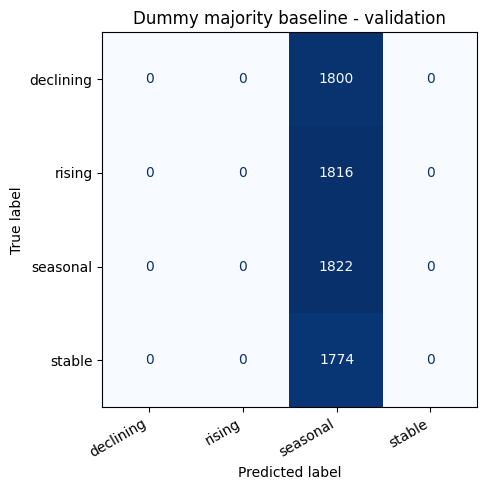

In [7]:
trained_models = {}
validation_metrics = []
validation_predictions = {}

model_name = "Dummy majority baseline"
estimator = DummyClassifier(strategy="most_frequent")

pipeline, metrics, preds = fit_and_validate(model_name, estimator)
trained_models[model_name] = pipeline
validation_metrics.append(metrics)
validation_predictions[model_name] = preds

plot_confusion(y_validation, preds, f"{model_name} - validation")

## 6. Traditional Machine Learning Models

This section compares linear, tree-based, ensemble, and large-margin models under the same preprocessing pipeline.

In [8]:
traditional_estimators = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=18,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=150,
        l2_regularization=0.01,
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=5000,
    ),
}

for model_name, estimator in traditional_estimators.items():
    print(f"\n=== {model_name} ===")
    pipeline, metrics, preds = fit_and_validate(model_name, estimator)
    trained_models[model_name] = pipeline
    validation_metrics.append(metrics)
    validation_predictions[model_name] = preds


=== Logistic Regression ===


,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds
0,Logistic Regression,validation,0.2408,0.2406,0.2408,0.2406,0.2406,3.797


              precision    recall  f1-score   support

   declining       0.24      0.25      0.25      1800
      rising       0.24      0.22      0.23      1816
    seasonal       0.25      0.26      0.25      1822
      stable       0.23      0.23      0.23      1774

    accuracy                           0.24      7212
   macro avg       0.24      0.24      0.24      7212
weighted avg       0.24      0.24      0.24      7212


=== Decision Tree ===


,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds
0,Decision Tree,validation,0.2476,0.2487,0.2473,0.2426,0.2428,2.3803


              precision    recall  f1-score   support

   declining       0.24      0.16      0.19      1800
      rising       0.24      0.36      0.29      1816
    seasonal       0.27      0.25      0.26      1822
      stable       0.25      0.22      0.23      1774

    accuracy                           0.25      7212
   macro avg       0.25      0.25      0.24      7212
weighted avg       0.25      0.25      0.24      7212


=== Random Forest ===


...

              precision    recall  f1-score   support

   declining       0.24      0.24      0.24      1800
      rising       0.25      0.27      0.26      1816
    seasonal       0.26      0.27      0.27      1822
      stable       0.26      0.24      0.25      1774

    accuracy                           0.25      7212
   macro avg       0.25      0.25      0.25      7212
weighted avg       0.25      0.25      0.25      7212


=== Hist Gradient Boosting ===


,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds
0,Hist Gradient Boosting,validation,0.2475,0.2463,0.2466,0.2366,0.2371,2.9219


              precision    recall  f1-score   support

   declining       0.26      0.17      0.20      1800
      rising       0.23      0.27      0.25      1816
    seasonal       0.26      0.41      0.32      1822
      stable       0.23      0.14      0.18      1774

    accuracy                           0.25      7212
   macro avg       0.25      0.25      0.24      7212
weighted avg       0.25      0.25      0.24      7212


=== Linear SVM ===


,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds
0,Linear SVM,validation,0.2415,0.2411,0.2414,0.241,0.2412,9.4042


              precision    recall  f1-score   support

   declining       0.24      0.25      0.25      1800
      rising       0.24      0.23      0.24      1816
    seasonal       0.25      0.27      0.26      1822
      stable       0.23      0.21      0.22      1774

    accuracy                           0.24      7212
   macro avg       0.24      0.24      0.24      7212
weighted avg       0.24      0.24      0.24      7212



In [9]:
traditional_results = (
    pd.DataFrame(validation_metrics)
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(traditional_results.round(4))

,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds
0,Random Forest,validation,0.2547,0.2546,0.2546,0.2544,0.2545,9.2878
1,Decision Tree,validation,0.2476,0.2487,0.2473,0.2426,0.2428,2.3803
2,Linear SVM,validation,0.2415,0.2411,0.2414,0.2410,0.2412,9.4042
3,Logistic Regression,validation,0.2408,0.2406,0.2408,0.2406,0.2406,3.7970
4,Hist Gradient Boosting,validation,0.2475,0.2463,0.2466,0.2366,0.2371,2.9219
5,Dummy majority baseline,validation,0.2526,0.0632,0.2500,0.1008,0.1019,0.3099


## 7. Neural Network Model

Use an `MLPClassifier` as the neural-network comparison point. This keeps the notebook within the current project dependencies while still testing a multi-layer neural architecture.

In [10]:
model_name = "MLP Neural Network"
estimator = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    batch_size=256,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=8,
    max_iter=80,
    random_state=RANDOM_STATE,
)

pipeline, metrics, preds = fit_and_validate(model_name, estimator)
trained_models[model_name] = pipeline
validation_metrics.append(metrics)
validation_predictions[model_name] = preds

plot_confusion(y_validation, preds, f"{model_name} - validation")

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

## 8. Validation Comparison

Rank all candidate models on validation macro F1, then inspect runtime and accuracy as secondary signals.

In [ ]:
validation_results = (
    pd.DataFrame(validation_metrics)
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(validation_results.round(4))

ax = validation_results.plot(
    x="model",
    y=["accuracy", "macro_f1", "weighted_f1"],
    kind="bar",
    figsize=(10, 5),
    rot=35,
)
ax.set_title("Validation performance by model")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
top_model_names = validation_results.head(3)["model"].tolist()
print("Top validation models:")
for name in top_model_names:
    print(f"- {name}")
    plot_confusion(y_validation, validation_predictions[name], f"{name} - validation")

## 9. Final Test Evaluation

Only evaluate the strongest validation models on the test set. This keeps the test set as a final check rather than a tuning tool.

In [ ]:
test_metrics = []
test_predictions = {}

for model_name in top_model_names:
    pipeline = trained_models[model_name]
    preds = pipeline.predict(X_test)
    test_predictions[model_name] = preds
    test_metrics.append(evaluate_predictions(model_name, "test", y_test, preds))

test_results = (
    pd.DataFrame(test_metrics)
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(test_results.round(4))

for model_name in test_results["model"]:
    print(f"\n=== {model_name} - test ===")
    print(classification_report(y_test, test_predictions[model_name], zero_division=0))
    plot_confusion(y_test, test_predictions[model_name], f"{model_name} - test")

## 10. Notes For Report Interpretation

Use the completed tables above to answer RQ3 around four points:

- Which model achieved the strongest validation and test macro F1?
- Did the MLP neural network outperform classical or ensemble models?
- Was any performance gain worth the extra training time and lower interpretability?
- Which classes were most often confused, based on the confusion matrices?

No files are saved by this notebook. If the final results look stable, a later step can add explicit exports for report tables and figures.